In [1]:
from psrqpy.utils import get_glitch_catalogue
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 14,          # Base font size
    'axes.titlesize': 18,     # Title font size
    'axes.labelsize': 16,     # Axis label font size
    'xtick.labelsize': 14,    # X-axis tick font size
    'ytick.labelsize': 14,    # Y-axis tick font size
})

glitches = get_glitch_catalogue()

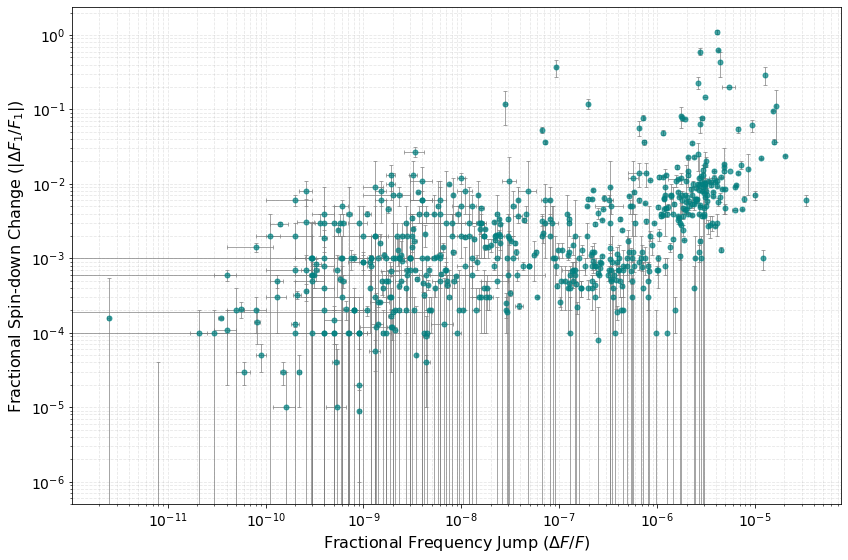

In [17]:
df = glitches.to_pandas()


plot_df = df.dropna(subset=['DeltaF/F', 'DeltaF1/F1']).copy()

# 2. Ensure columns are numeric to avoid plotting errors
cols = ['DeltaF/F', 'DeltaF/F_ERR', 'DeltaF1/F1', 'DeltaF1/F1_ERR']
for col in cols:
    plot_df[col] = pd.to_numeric(plot_df[col], errors='coerce')

# 3. Create the scatter plot
fig, ax = plt.subplots(figsize=(12, 8))

ax.errorbar(
    plot_df['DeltaF/F'], 
    np.abs(plot_df['DeltaF1/F1']), 
    xerr=plot_df['DeltaF/F_ERR'], 
    yerr=plot_df['DeltaF1/F1_ERR'], 
    fmt='o', 
    color='teal', 
    ecolor='gray', 
    elinewidth=1, 
    capsize=2, 
    alpha=0.7,
    markersize=5
)

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel(r'Fractional Frequency Jump ($\Delta F / F$)')
ax.set_ylabel(r'Fractional Spin-down Change ($|\Delta F_1 / F_1|$)')

ax.grid(True, which='both', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
from psrqpy import QueryATNF

# 1. Download the Glitch Catalog
df_glitches = get_glitch_catalogue().to_pandas()

# 2. Download the F0 and F1 values from the main ATNF Catalog
# PSRJ = Pulsar Name, F0 = Frequency (Hz), F1 = Spin-down rate (Hz/s)
query = QueryATNF(params=['PSRJ', 'F0', 'F1'])
df_atnf = query.pandas

# Rename 'PSRJ' to 'JNAME' so it matches the glitch catalog's column name
df_atnf = df_atnf.rename(columns={'PSRJ': 'JNAME'})

# 3. Merge the two databases together!
# This looks at the JNAME in the glitch table and pulls the matching F0 from the ATNF table
df_merged = pd.merge(df_glitches, df_atnf, on='JNAME', how='left')

# Force the F0 and fractional jump columns to be numeric just in case
df_merged['F0'] = pd.to_numeric(df_merged['F0'], errors='coerce')
df_merged['DeltaF/F'] = pd.to_numeric(df_merged['DeltaF/F'], errors='coerce')

df_merged['F1'] = pd.to_numeric(df_merged['F1'], errors='coerce')
df_merged['DeltaF1/F1'] = pd.to_numeric(df_merged['DeltaF1/F1'], errors='coerce')


# 4. (Optional) Calculate the ABSOLUTE frequency jump (Delta F) in Hertz
df_merged['DeltaF'] = df_merged['DeltaF/F'] * df_merged['F0']

df_merged['DeltaF1'] = df_merged['DeltaF1/F1'] * df_merged['F1']

# Take a look at the results!
print(df_merged[['JNAME', 'MJD', 'F0', 'DeltaF/F', 'DeltaF', 'F1', 'DeltaF1/F1', 'DeltaF1']].head())

        JNAME       MJD         F0      DeltaF/F        DeltaF            F1  \
0  J0007+7303  54953.00   3.165827  5.540000e-07  1.753868e-06 -3.612000e-12   
1  J0007+7303  55466.00   3.165827  1.260000e-06  3.988943e-06 -3.612000e-12   
2  J0040-7335  59919.70   6.886188  1.310000e-09  9.020906e-09 -1.131080e-12   
3  J0040-7335  60355.80   6.886188  1.900000e-09  1.308376e-08 -1.131080e-12   
4  J0040-7337  60013.13  16.697679  1.810000e-06  3.022280e-05 -9.491000e-12   

   DeltaF1/F1       DeltaF1  
0    0.001000 -3.612000e-15  
1         NaN           NaN  
2    0.000056 -6.334048e-17  
3    0.000680 -7.691344e-16  
4    0.007000 -6.643700e-14  


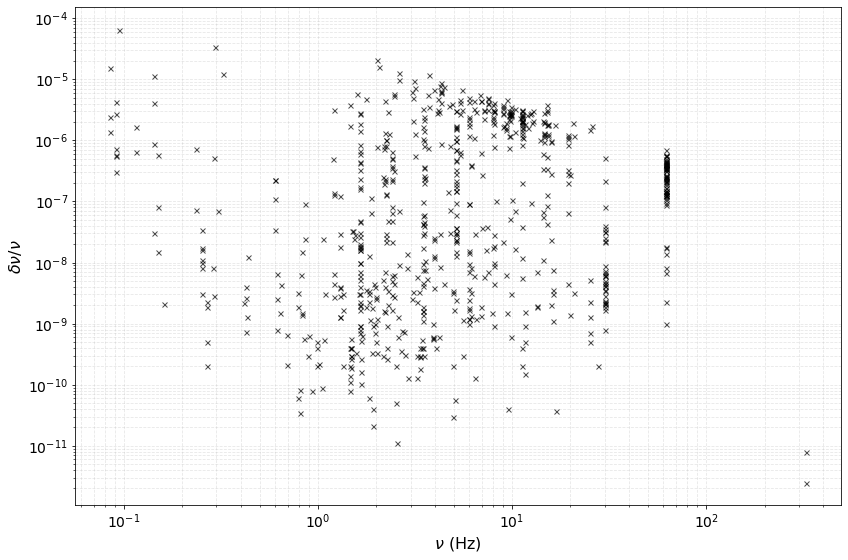

In [15]:

plot_df = df_merged.dropna(subset=['F0', 'DeltaF/F']).copy()

# 2. Ensure columns are numeric to avoid plotting errors
cols = ['F0', 'DeltaF/F']
for col in cols:
    plot_df[col] = pd.to_numeric(plot_df[col], errors='coerce')

# 3. Create the scatter plot
fig, ax = plt.subplots(figsize=(12, 8))

ax.errorbar(
    plot_df['F0'], 
    plot_df['DeltaF/F'], 
    # xerr=plot_df['DeltaF/F_ERR'], 
    # yerr=plot_df['DeltaF1/F1_ERR'], 
    fmt='x', 
    color='k', 
    ecolor='gray', 
    elinewidth=1, 
    capsize=2, 
    alpha=0.7,
    markersize=5
)

# Use log scales because pulsar glitches span many orders of magnitude
ax.set_xscale('log')
ax.set_yscale('log')

# Set labels
ax.set_xlabel(r'$\nu~\mathrm{(Hz)}$')
ax.set_ylabel(r'$\delta \nu/\nu$')
# ax.set_title(r'Pulsar Glitches: $\Delta F / F$ vs $|\Delta F_1 / F_1|$')

# Add a grid for easier reading
ax.grid(True, which='both', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

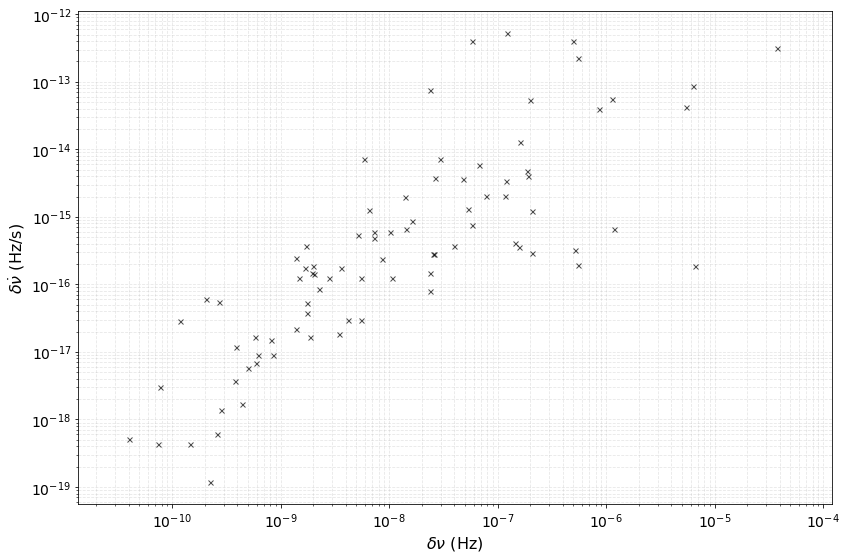

In [19]:

plot_df = df_merged.dropna(subset=['DeltaF', 'DeltaF1']).copy()

# 2. Ensure columns are numeric to avoid plotting errors
cols = ['DeltaF', 'DeltaF1']
for col in cols:
    plot_df[col] = pd.to_numeric(plot_df[col], errors='coerce')

# 3. Create the scatter plot
fig, ax = plt.subplots(figsize=(12, 8))

ax.errorbar(
    plot_df['DeltaF'], 
    plot_df['DeltaF1'], 
    # xerr=plot_df['DeltaF/F_ERR'], 
    # yerr=plot_df['DeltaF1/F1_ERR'], 
    fmt='x', 
    color='k', 
    ecolor='gray', 
    elinewidth=1, 
    capsize=2, 
    alpha=0.7,
    markersize=5
)

# Use log scales because pulsar glitches span many orders of magnitude
ax.set_xscale('log')
ax.set_yscale('log')

# Set labels
ax.set_xlabel(r'$\delta \nu~\mathrm{(Hz)}$')
ax.set_ylabel(r'$\delta \dot{\nu}~\mathrm{(Hz/s)}$')
# ax.set_title(r'Pulsar Glitches: $\Delta F / F$ vs $|\Delta F_1 / F_1|$')

# Add a grid for easier reading
ax.grid(True, which='both', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()